# Trading Workshop 3: Risk & Performance Metrics

Workshop 1 built a portfolio and workshop 2 built a trading strategy. In both cases we mostly looked at **returns**. But a strategy that returns +50% with wild swings and a strategy that returns +50% smoothly are not equally good — we need tools to judge return *relative to the risk taken*.

In this notebook we implement, from their formulas, the risk and performance metrics that are used everywhere in the industry to evaluate a portfolio or a strategy:

- **Sharpe ratio** — return per unit of total volatility
- **Sortino ratio** — return per unit of *downside* volatility only
- **Maximum drawdown** — the worst peak-to-trough loss
- **Value at Risk (VaR)** — how much you can lose over a given horizon, with a given confidence level
- **CAPM alpha / beta** — how an asset behaves relative to the overall market

We apply these metrics to a handful of stocks and to the S&P 500 as a market benchmark, using `yfinance` — everything below runs end to end with no external files.

In [1]:
# If a package is missing (e.g. on Google Colab), uncomment the line below:
# %pip install -r requirements.txt

In [2]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import plotly.graph_objects as go
import plotly.io as pio

pio.templates.default = "plotly_white"
# Static (PNG) rendering keeps the charts visible both in Jupyter and on GitHub.
pio.renderers.default = "png"


## Step 1: Fetching the data

We use four stocks and the S&P 500 index (`^GSPC`) as the market benchmark, over three years of daily data.

In [3]:
assets = ['AAPL', 'MSFT', 'TSLA', 'NVDA']
benchmark = '^GSPC'
tickers = assets + [benchmark]

N = 365 * 3  # three years of history
start_date = dt.datetime.now() - dt.timedelta(days=N)
end_date = dt.datetime.now()

prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']
returns = prices.pct_change().dropna()
returns.tail()

[                       0%                       ]

[**********************60%****                   ]  3 of 5 completed

[**********************80%*************          ]  4 of 5 completed

[*********************100%***********************]  5 of 5 completed

Ticker,AAPL,MSFT,NVDA,TSLA,^GSPC
Date,,,,,
2026-09-16,0.003229,-0.013719,0.008154,0.004207,-0.004472
2026-09-17,0.013808,0.015195,0.025432,0.022677,0.011381
2026-09-18,-0.002582,-0.007976,0.013358,-0.005270,0.001668
2026-09-21,0.008479,0.015857,0.022990,0.030280,0.014927
2026-09-22,0.002271,-0.007197,0.006553,0.009592,-0.000008


## Step 2: Sharpe ratio

The Sharpe ratio measures the excess return earned per unit of volatility:

$$
\text{Sharpe} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_p}
$$

Where $R_f$ is the risk-free rate. We annualize daily returns/volatility by multiplying by $\sqrt{252}$ (the usual number of trading days in a year).

In [4]:
def sharpe_ratio(returns, risk_free_rate=0.0, periods_per_year=252):
    # returns: series or dataframe of periodic returns
    # risk_free_rate: annualized risk-free rate (e.g. 0.03 for 3%)
    excess_returns = returns - risk_free_rate / periods_per_year
    return np.sqrt(periods_per_year) * excess_returns.mean() / returns.std()

sharpe = sharpe_ratio(returns[assets], risk_free_rate=0.03)
sharpe.sort_values(ascending=False)

Ticker
NVDA    1.383633
AAPL    0.861624
MSFT    0.621366
TSLA    0.483468
dtype: float64

## Step 3: Sortino ratio

The Sharpe ratio penalizes *any* volatility, even upside surprises. The Sortino ratio only penalizes **downside** volatility, which is usually what investors actually care about:

$$
\text{Sortino} = \frac{\mathbb{E}[R_p] - R_f}{\sigma_{p}^{-}}
\quad \text{where} \quad
\sigma_{p}^{-} = \sqrt{\frac{1}{T}\sum_{t=1}^T \min(R_t - R_f, 0)^2}
$$

In [5]:
def sortino_ratio(returns, risk_free_rate=0.0, periods_per_year=252):
    # returns: series or dataframe of periodic returns
    daily_rf = risk_free_rate / periods_per_year
    excess_returns = returns - daily_rf
    downside = excess_returns.clip(upper=0)
    downside_std = np.sqrt((downside ** 2).mean())
    return np.sqrt(periods_per_year) * excess_returns.mean() / downside_std

sortino = sortino_ratio(returns[assets], risk_free_rate=0.03)
sortino.sort_values(ascending=False)

Ticker
NVDA    2.096671
AAPL    1.285875
MSFT    0.942229
TSLA    0.730154
dtype: float64

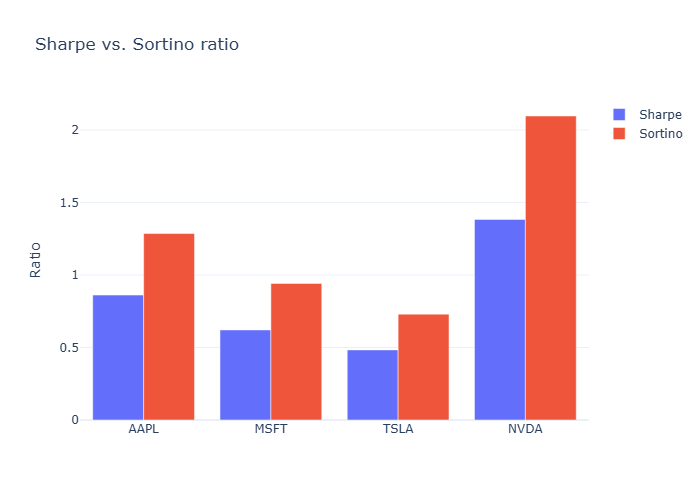

In [6]:
fig = go.Figure()
fig.add_trace(go.Bar(x=assets, y=sharpe[assets], name='Sharpe'))
fig.add_trace(go.Bar(x=assets, y=sortino[assets], name='Sortino'))
fig.update_layout(title='Sharpe vs. Sortino ratio', barmode='group', yaxis_title='Ratio')
fig.show()

## Step 4: Maximum drawdown

The maximum drawdown is the largest observed loss from a peak to a subsequent trough of the cumulative return curve:

$$
\text{Drawdown}_t = \frac{V_t - \max_{s \le t} V_s}{\max_{s \le t} V_s}, \qquad \text{MDD} = \min_t \text{Drawdown}_t
$$

Where $V_t$ is the value of the portfolio (or 1$ invested in the asset) at time $t$.

In [7]:
def compute_drawdown(returns):
    # returns: series of periodic returns for a single asset
    # Returns the cumulative value curve and the drawdown series.
    cumulative_value = (1 + returns).cumprod()
    running_max = cumulative_value.cummax()
    drawdown = cumulative_value / running_max - 1
    return cumulative_value, drawdown

max_drawdown = {a: compute_drawdown(returns[a])[1].min() for a in assets}
pd.Series(max_drawdown, name='Max Drawdown').sort_values()

TSLA   -0.537657
NVDA   -0.368810
MSFT   -0.344984
AAPL   -0.333605
Name: Max Drawdown, dtype: float64

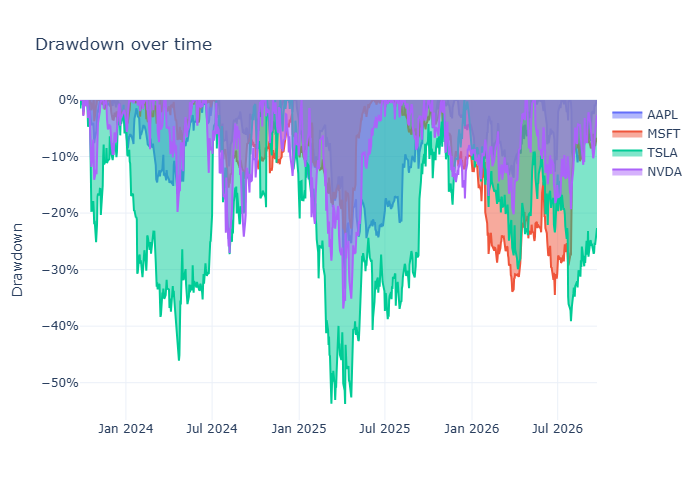

In [8]:
fig = go.Figure()
for a in assets:
    _, drawdown = compute_drawdown(returns[a])
    fig.add_trace(go.Scatter(x=drawdown.index, y=drawdown, name=a, fill='tozeroy'))
fig.update_layout(title='Drawdown over time', yaxis_title='Drawdown', yaxis_tickformat='.0%')
fig.show()

## Step 5: Value at Risk (VaR)

The Value at Risk answers the question: *"What is the worst loss I can expect over one day, with a confidence level of $1-\alpha$?"*

**Historical VaR** simply takes the empirical quantile of past returns — no distribution assumption:
$$
\text{VaR}_\alpha = -\text{quantile}_\alpha(R)
$$

**Parametric (Gaussian) VaR** assumes returns are normally distributed:
$$
\text{VaR}_\alpha = -(\mu + \sigma \cdot z_\alpha)
$$
where $z_\alpha$ is the $\alpha$-quantile of the standard normal distribution (e.g. $z_{0.05} \approx -1.645$).

In [9]:
from scipy.stats import norm

def historical_var(returns, alpha=0.05):
    return -returns.quantile(alpha)

def parametric_var(returns, alpha=0.05):
    mu, sigma = returns.mean(), returns.std()
    z = norm.ppf(alpha)
    return -(mu + sigma * z)

var_table = pd.DataFrame({
    'Historical VaR (95%)': {a: historical_var(returns[a]) for a in assets},
    'Parametric VaR (95%)': {a: parametric_var(returns[a]) for a in assets},
})
var_table

,Historical VaR (95%),Parametric VaR (95%)
AAPL,0.025060,0.026767
MSFT,0.024489,0.026428
TSLA,0.051602,0.059021
NVDA,0.042530,0.045914


A 1-day 95% VaR of 3% means that, historically, the asset lost more than 3% in a single day only 5% of the time.

## Step 6: CAPM alpha and beta

The Capital Asset Pricing Model explains an asset's return through its sensitivity to the overall market:

$$
R_i - R_f = \alpha_i + \beta_i (R_m - R_f) + \varepsilon_i
$$

- $\beta_i$ measures how much the asset moves with the market (systematic risk). $\beta_i > 1$ means the asset amplifies market moves.
- $\alpha_i$ measures the asset's average return *beyond* what its beta would predict — the holy grail active managers look for.

We estimate $\alpha_i$ and $\beta_i$ with a simple linear regression of excess asset returns on excess market returns.

In [10]:
def capm_alpha_beta(asset_returns, market_returns, risk_free_rate=0.0, periods_per_year=252):
    # asset_returns, market_returns: aligned series of periodic returns
    # Returns annualized alpha and beta.
    daily_rf = risk_free_rate / periods_per_year
    excess_asset = asset_returns - daily_rf
    excess_market = market_returns - daily_rf

    beta, alpha_daily = np.polyfit(excess_market, excess_asset, deg=1)
    alpha_annualized = alpha_daily * periods_per_year
    return alpha_annualized, beta

capm_table = pd.DataFrame(
    {a: capm_alpha_beta(returns[a], returns[benchmark], risk_free_rate=0.03) for a in assets},
    index=['Alpha (ann.)', 'Beta'],
).T
capm_table

,Alpha (ann.),Beta
AAPL,0.040644,1.076666
MSFT,-0.013830,0.999571
TSLA,-0.125819,2.299430
NVDA,0.277205,2.101206


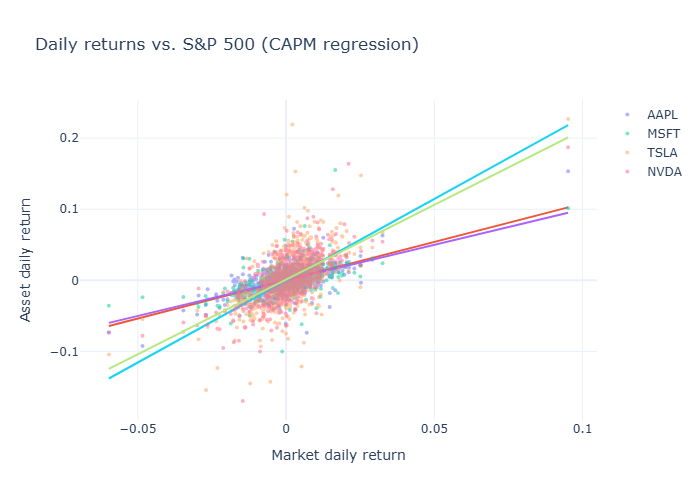

In [11]:
fig = go.Figure()
for a in assets:
    fig.add_trace(go.Scatter(x=returns[benchmark], y=returns[a], mode='markers',
                              marker=dict(size=4), name=a, opacity=0.5))
    beta, alpha_daily = np.polyfit(returns[benchmark], returns[a], deg=1)
    x_line = np.linspace(returns[benchmark].min(), returns[benchmark].max(), 2)
    fig.add_trace(go.Scatter(x=x_line, y=alpha_daily + beta * x_line, mode='lines',
                              line=dict(width=2), name=f'{a} fit', showlegend=False))
fig.update_layout(title='Daily returns vs. S&P 500 (CAPM regression)',
                   xaxis_title='Market daily return', yaxis_title='Asset daily return')
fig.show()

## Summary

In [12]:
summary = pd.DataFrame({
    'Sharpe': sharpe[assets],
    'Sortino': sortino[assets],
    'Max Drawdown': pd.Series(max_drawdown),
    'Historical VaR (95%)': var_table['Historical VaR (95%)'],
    'Beta': capm_table['Beta'],
    'Alpha (ann.)': capm_table['Alpha (ann.)'],
})
summary.round(4)

,Sharpe,Sortino,Max Drawdown,Historical VaR (95%),Beta,Alpha (ann.)
AAPL,0.8616,1.2859,-0.3336,0.0251,1.0767,0.0406
MSFT,0.6214,0.9422,-0.3450,0.0245,0.9996,-0.0138
TSLA,0.4835,0.7302,-0.5377,0.0516,2.2994,-0.1258
NVDA,1.3836,2.0967,-0.3688,0.0425,2.1012,0.2772


## Conclusion

None of these metrics is sufficient on its own: a high Sharpe ratio can hide a large, rare drawdown; a low beta can hide a large idiosyncratic VaR; a positive alpha over one three-year window can be pure noise. In practice, you always look at several of these numbers together — and you eventually want to test whether they hold up out-of-sample, exactly like we did with the rebalancing backtest in workshop 1 and the strategy backtest in workshop 2.

**To go further:** try computing these metrics on the optimized portfolio from workshop 1, or on the equity curve produced by a strategy from workshop 2, instead of on individual stocks.